Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

Imports & Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score)

# Load CIFAR-10 dataset (60,000 32x32 color images, 10 classes)
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Label shape:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)  Test shape: (10000, 32, 32, 3)
Label shape: (50000, 1)


Task 1 — Dataset Understanding (10 Marks)

TASK 1: DATASET UNDERSTANDING

Training images: 50000
Testing images: 10000
Image dimensions: (32, 32, 3) (Height x Width x Channels)
Number of classes: 10
Pixel value range: 0 - 255

Class distribution (train):
         Class  Count
0    airplane   5000
1  automobile   5000
2        bird   5000
3         cat   5000
4        deer   5000
5         dog   5000
6        frog   5000
7       horse   5000
8        ship   5000
9       truck   5000


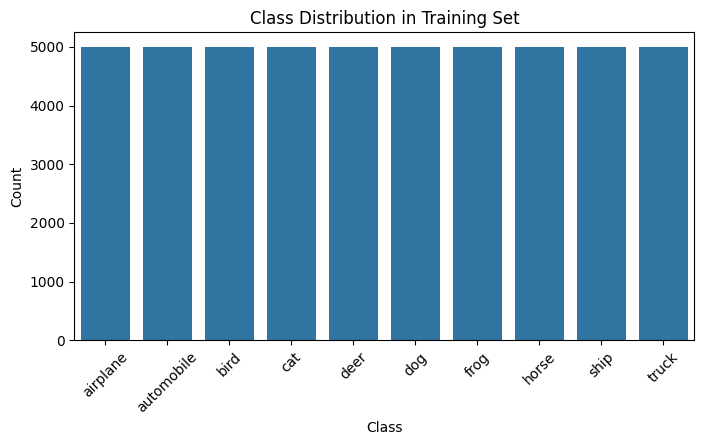

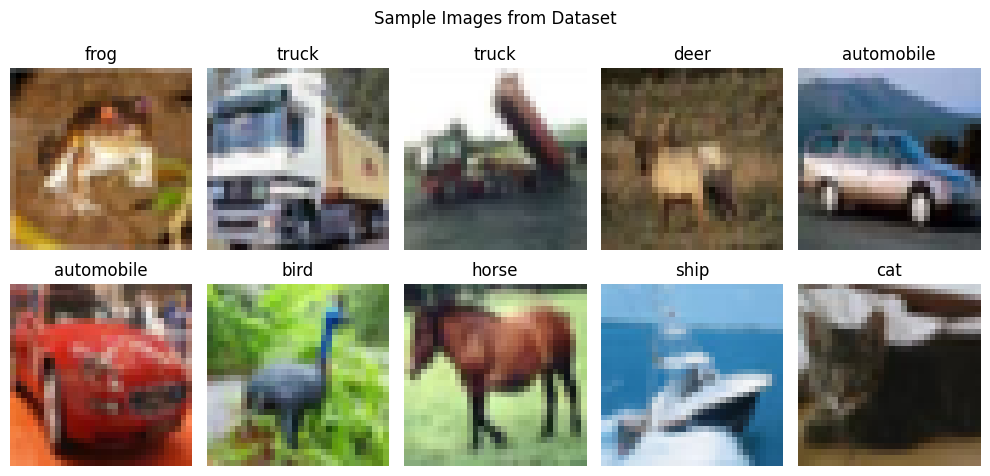

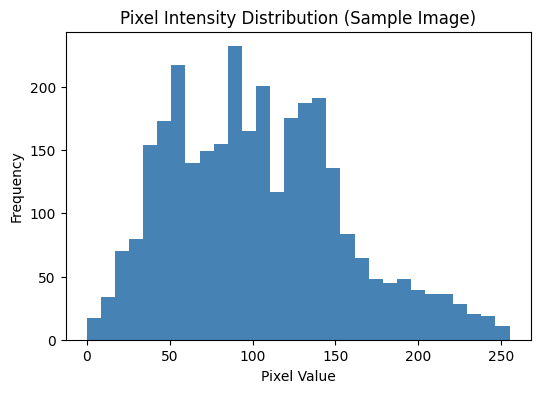

In [ ]:
print("="*60)
print("TASK 1: DATASET UNDERSTANDING")
print("="*60)

print("\nTraining images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])
print("Image dimensions:", X_train.shape[1:], "(Height x Width x Channels)")
print("Number of classes:", len(class_names))
print("Pixel value range:", X_train.min(), "-", X_train.max())

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
dist_df = pd.DataFrame({'Class': [class_names[i] for i in unique], 'Count': counts})
print("\nClass distribution (train):\n", dist_df)

plt.figure(figsize=(8,4))
sns.barplot(x='Class', y='Count', data=dist_df)
plt.title('Class Distribution in Training Set')
plt.xticks(rotation=45)
plt.show()

# Sample images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle("Sample Images from Dataset")
plt.tight_layout()
plt.show()

# Pixel intensity distribution
plt.figure(figsize=(6,4))
plt.hist(X_train[0].flatten(), bins=30, color='steelblue')
plt.title('Pixel Intensity Distribution (Sample Image)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

Task 2 — Data Cleaning (20 Marks)

In [ ]:
print("="*60)
print("TASK 2: DATA CLEANING")
print("="*60)

# Check for missing/corrupted images (NaNs)
print("Any NaN in training images:", np.isnan(X_train).any())
print("Any NaN in test images:", np.isnan(X_test).any())

# Check for duplicate images (hashing approach)
def find_duplicates(images, sample_size=2000):
    seen = set()
    duplicates = 0
    for img in images[:sample_size]:
        h = hash(img.tobytes())
        if h in seen:
            duplicates += 1
        seen.add(h)
    return duplicates

dup_count = find_duplicates(X_train)
print(f"Duplicate images found (sample of 2000): {dup_count}")

# Check for completely blank/corrupted images (all zero or all same value)
blank_images = np.sum([np.all(img == img[0,0,0]) for img in X_train[:2000]])
print(f"Blank/corrupted images found (sample of 2000): {blank_images}")

# Remove any NaN entries (precautionary, CIFAR-10 has none but good practice)
valid_idx_train = ~np.isnan(X_train).any(axis=(1,2,3))
valid_idx_test = ~np.isnan(X_test).any(axis=(1,2,3))
X_train, y_train = X_train[valid_idx_train], y_train[valid_idx_train]
X_test, y_test = X_test[valid_idx_test], y_test[valid_idx_test]

print("\nShape after cleaning -> Train:", X_train.shape, " Test:", X_test.shape)

# Normalize pixel values to [0, 1] (standard image cleaning step)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Pixel range after normalization:", X_train.min(), "-", X_train.max())

TASK 2: DATA CLEANING
Any NaN in training images: False
Any NaN in test images: False
Duplicate images found (sample of 2000): 0
Blank/corrupted images found (sample of 2000): 0

Shape after cleaning -> Train: (50000, 32, 32, 3)  Test: (10000, 32, 32, 3)
Pixel range after normalization: 0.0 - 1.0


Task 3 — Feature Engineering (15 Marks)

TASK 3: FEATURE ENGINEERING
Label shape after one-hot encoding: (50000, 10)


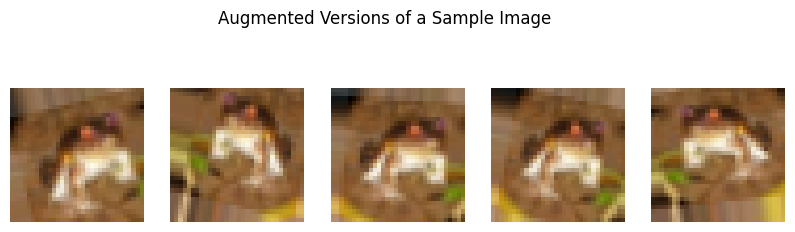


Final Train shape: (45000, 32, 32, 3)
Validation shape: (5000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [ ]:
print("="*60)
print("TASK 3: FEATURE ENGINEERING")
print("="*60)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)
print("Label shape after one-hot encoding:", y_train_cat.shape)

# Data augmentation = engineered/generated features for CNN robustness
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

# Visualize augmented samples (feature engineering effect)
sample_img = X_train[0].reshape((1,32,32,3))
aug_iter = datagen.flow(sample_img, batch_size=1)

plt.figure(figsize=(10,3))
for i in range(5):
    aug_img = next(aug_iter)[0]
    plt.subplot(1,5,i+1)
    plt.imshow(aug_img)
    plt.axis('off')
plt.suptitle("Augmented Versions of a Sample Image")
plt.show()

# Split a validation set from training data
from sklearn.model_selection import train_test_split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train_cat, test_size=0.1, random_state=42
)

print("\nFinal Train shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Task 4 — Model Building (30 Marks)

In [ ]:
print("="*60)
print("TASK 4: MODEL BUILDING (CNN)")
print("="*60)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = model.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=25,
    callbacks=callbacks
)

TASK 4: MODEL BUILDING (CNN)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 194s 271ms/step - accuracy: 0.3473 - loss: 1.7926 - val_accuracy: 0.4198 - val_loss: 1.6416 - learning_rate: 0.0010
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 192s 273ms/step - accuracy: 0.4793 - loss: 1.4428 - val_accuracy: 0.4736 - val_loss: 1.4547 - learning_rate: 0.0010
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 274ms/step - accuracy: 0.5490 - loss: 1.2682 - val_accuracy: 0.5698 - val_loss: 1.2793 - learning_rate: 0.0010
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 198s 280ms/step - accuracy: 0.5923 - loss: 1.1519 - val_accuracy: 0.6158 - val_loss: 1.1935 - learning_rate: 0.0010
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 194s 276ms/step - accuracy: 0.6283 - loss: 1.0670 - val_accuracy: 0.6806 - val_loss: 0.9182 - learning_rate: 0.0010
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 193s 275ms/step - accuracy: 0.6492 - loss: 1.0209 - val_accuracy: 0.6952 - val_loss: 0.8496 - learning_rate: 0.0010
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 192s 273ms/step - accura

Task 5 — Performance Evaluation (15 Marks)

TASK 5: PERFORMANCE EVALUATION


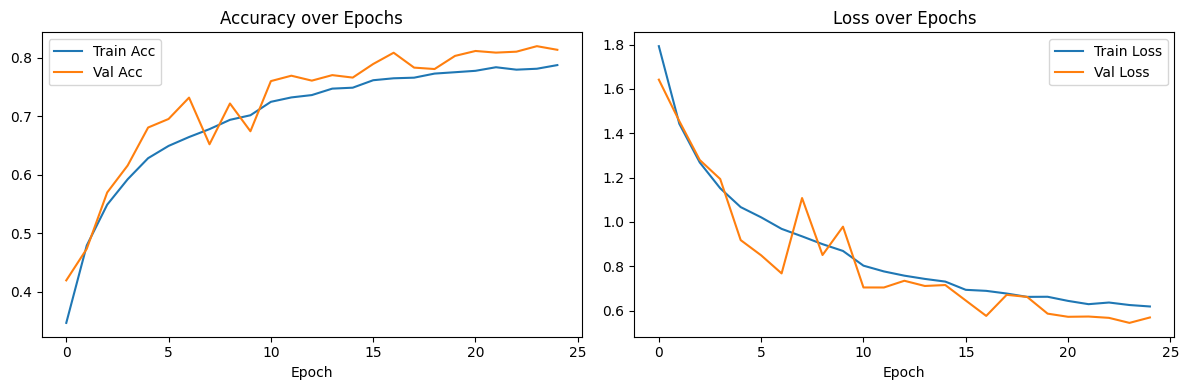


Test Accuracy: 0.8115
Test Loss: 0.5735
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step

Overall Accuracy: 0.8115
Macro Precision: 0.8200
Macro Recall: 0.8115
Macro F1 Score: 0.8080

Classification Report:

              precision    recall  f1-score   support

    airplane       0.83      0.85      0.84      1000
  automobile       0.92      0.93      0.93      1000
        bird       0.81      0.68      0.74      1000
         cat       0.77      0.54      0.64      1000
        deer       0.78      0.81      0.79      1000
         dog       0.86      0.64      0.73      1000
        frog       0.63      0.96      0.76      1000
       horse       0.85      0.86      0.85      1000
        ship       0.90      0.92      0.91      1000
       truck       0.84      0.92      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



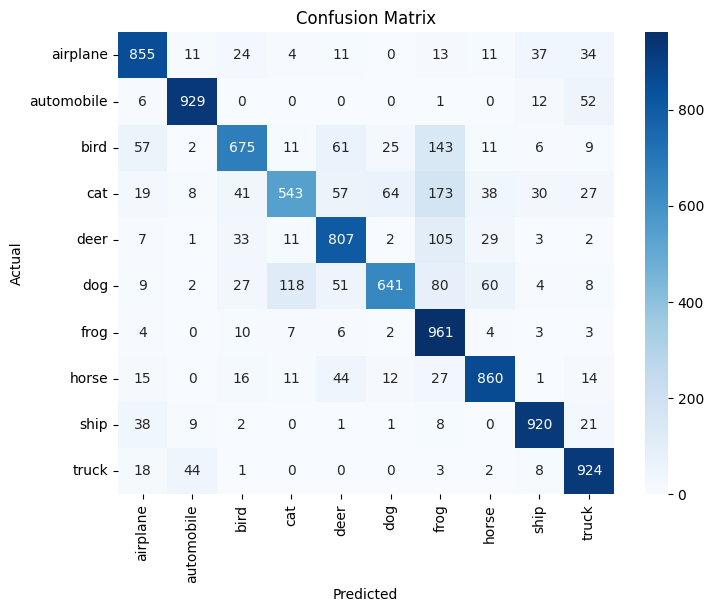

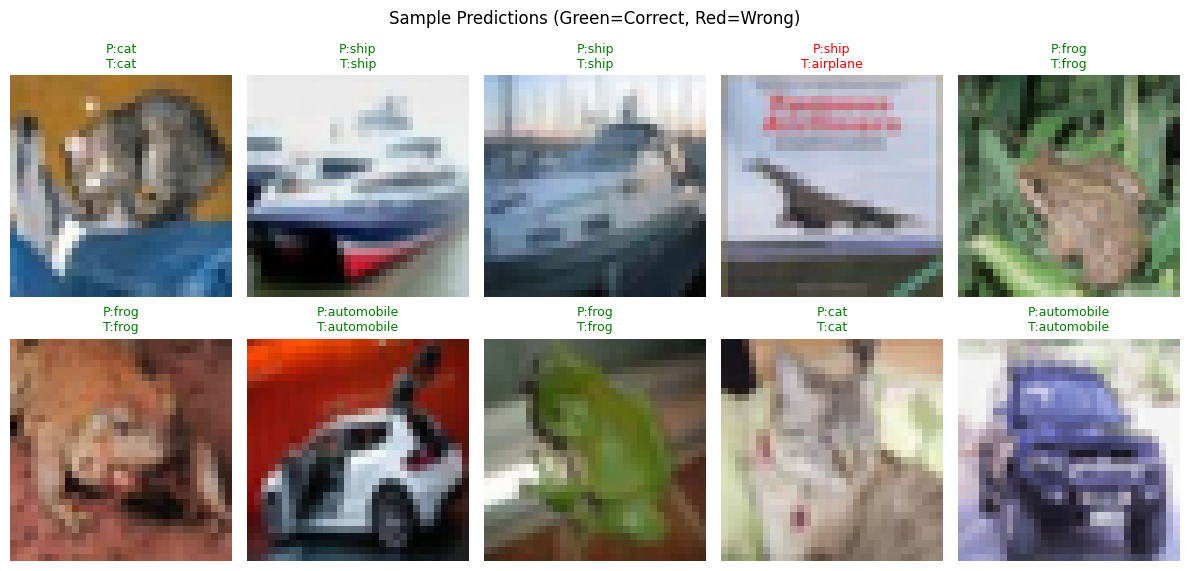

In [ ]:
print("="*60)
print("TASK 5: PERFORMANCE EVALUATION")
print("="*60)

# Training curves
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"\nOverall Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall: {rec:.4f}")
print(f"Macro F1 Score: {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Sample predictions visualization
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    pred_label = class_names[y_pred[i]]
    true_label = class_names[y_true[i]]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"P:{pred_label}\nT:{true_label}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()